In [23]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from qutip import qload
from joblib import load
from extracter import *
from fitting_model import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

We start by analyzing the performance of one fold and analyze average 48 times

In [143]:
num_ft = 4
fold_num = 40
rep = 1

# load features
data = pd.read_csv(f"leaveoneout/{num_ft}fts{fold_num}_{rep}rep.csv")
# load fold
y_train = load(f'leaveoneout/fold_{fold_num}.joblib')['y_train'] # unload y_train
target_train = [int(i) for i in y_train][::num_ft] # store y_train while skipping the repetition
y_test = load(f'leaveoneout/fold_{fold_num}.joblib')['y_test'] # unload y_test
target_test = [int(i) for i in y_test][::num_ft] # store y_test while skipping the repetition
target_train.extend(target_test) # combine y_train,y_test as one

len(target_train)

48

In [145]:
# training parameters
delay_points = 2
train_points = 45
total_points = 48

In [224]:
X = extract_block_single_column_pq(data ,column_name="PQ-15",N_fts=num_ft,n_samples=48,skip_steps=rep)
print(X)
X_train = X[delay_points:train_points+delay_points]
X_test = X[train_points+delay_points:]

y_train = target_train[delay_points:train_points+delay_points] # separate into train and test
y_test = target_train[train_points+delay_points:]
W = fitting_function(X_train, y_train) # find the weight matrix
y_prediction = predict(X_test, W) # find the final prediction

y_train_pred = predict(X_train, W) # find the final prediction

y_pred = np.concatenate(([0,0],y_train_pred, y_prediction))
X_train.shape

[[ 0.00694375  0.01202692  0.02101705  0.0364026   0.02881931  0.0499165
   0.03618338  0.06267145]
 [ 0.0434411   0.07524219  0.04987525  0.08638647  0.05533436  0.09584192
   0.05600208  0.09699845]
 [ 0.0725155   0.12560053  0.09434174  0.16340469  0.10267146  0.17783218
   0.105251    0.18230008]
 [ 0.10238748  0.17734031  0.09774158  0.16929339  0.09311005  0.16127135
   0.10209538  0.15276697]
 [ 0.12436931  0.1424618   0.1309243   0.12619453  0.13169046  0.10058901
   0.12859478  0.06769407]
 [ 0.13268696  0.04964388  0.14339569  0.04712083  0.14385246  0.04451246
   0.17577916  0.04236964]
 [ 0.21854658  0.04125697  0.23401619  0.04046793  0.23831929  0.04116593
   0.23154492  0.04204161]
 [ 0.22064072  0.0426197   0.21354312  0.04997224  0.21046313  0.06452384
   0.20390477  0.07527731]
 [ 0.19418966  0.09060878  0.17899632  0.11086624  0.15569016  0.12663264
   0.14192863  0.12544007]
 [ 0.13775695  0.11093824  0.12641516  0.08744036  0.10852383  0.05563961
   0.0901062   0.0

(45, 8)

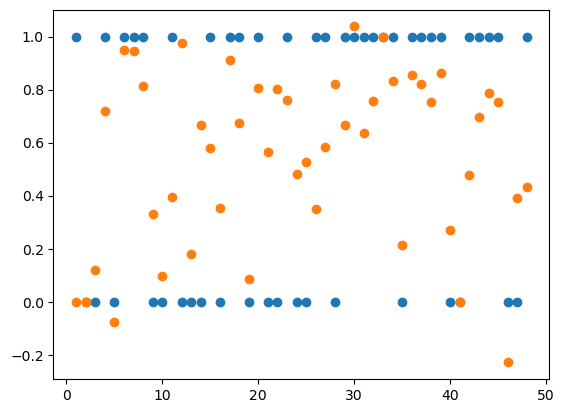

In [149]:
x = np.linspace(1,48,48)
plt.scatter(x,target_train)
plt.scatter(x,y_pred)

testing the old result

In [159]:
num_ft = 4
fold_num = 1
rep = 1

# load features
data = pd.read_csv(f"fold/{num_ft}fts{fold_num}.csv")
# load fold
y_train = load(f'fold/fold_{fold_num}.joblib')['y_train'] # unload y_train
target_train = [int(i) for i in y_train][::num_ft] # store y_train while skipping the repetition
y_test = load(f'fold/fold_{fold_num}.joblib')['y_test'] # unload y_test
target_test = [int(i) for i in y_test][::num_ft] # store y_test while skipping the repetition
target_train.extend(target_test) # combine y_train,y_test as one

len(target_train)

48

In [161]:
# training parameters
delay_points = 2
train_points = 45
total_points = 48

In [173]:
X = extract_block_single_column_skip(data ,column_name="P0",N_fts=num_ft,n_samples=48,skip_steps=rep)
X_train = X[delay_points:train_points+delay_points]
X_test = X[train_points+delay_points:]

y_train = target_train[delay_points:train_points+delay_points] # separate into train and test
y_test = target_train[train_points+delay_points:]
W = fitting_function(X_train, y_train) # find the weight matrix
y_prediction = predict(X_test, W) # find the final prediction

y_train_pred = predict(X_train, W) # find the final prediction

y_pred = np.concatenate(([0,0],y_train_pred, y_prediction)) # the first two were used for delay
X_train.shape

(45, 4)

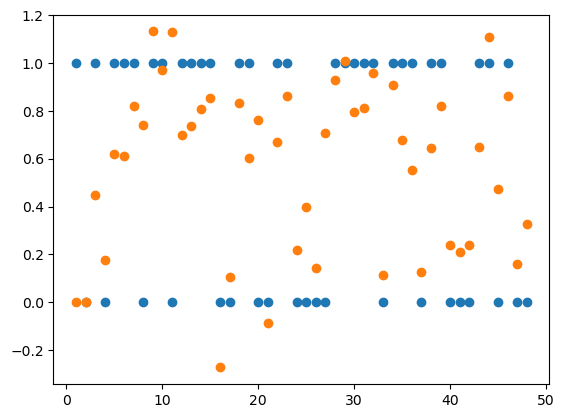

In [175]:
x = np.linspace(1,48,48)
plt.scatter(x,target_train)
plt.scatter(x,y_pred)

In [189]:
predictions = []
real_answers = []
y_pred_value = float(np.asarray(y_prediction).squeeze())
# threshold classification
if y_pred_value < 0.5:
    y_pred_class = 0
else:
    y_pred_class = 1

predictions.append(y_pred_class)
real_answers.append(int(np.asarray(y_test).squeeze()))
print("Predictions: ", predictions)
print("Real Answers: ", real_answers)

Predictions:  [0]
Real Answers:  [0]


Analyze the full set

In [285]:
num_ft = 4
rep = 1
delay_points = 2
train_points = 45
total_points = 48
predictions = []
real_answers = []
for fold_num in range(0,48): 
    # load features
    data = pd.read_csv(f"fold/{num_ft}fts{fold_num}repDifferentQuad.csv")
    # load fold
    y_train = load(f'fold/fold_{fold_num}.joblib')['y_train'] # unload y_train
    target_train = [int(i) for i in y_train][::num_ft] # store y_train while skipping the repetition
    y_test = load(f'fold/fold_{fold_num}.joblib')['y_test'] # unload y_test
    target_test = [int(i) for i in y_test][::num_ft] # store y_test while skipping the repetition
    target_train.extend(target_test) # combine y_train,y_test as one

    # Features splitting
    X = extract_block_single_column_pq(data ,column_name="PQ0",N_fts=num_ft,n_samples=48,skip_steps=rep)#extract_block_single_column_skip(data ,column_name="P0",N_fts=num_ft,n_samples=48,skip_steps=rep)
    X_train = X[delay_points:train_points+delay_points]
    X_test = X[train_points+delay_points:]
    # Target splitting
    y_train = target_train[delay_points:train_points+delay_points] # separate into train and test
    y_test = target_train[train_points+delay_points:]
    W = fitting_function(X_train, y_train) # find the weight matrix
    y_prediction = predict(X_test, W) # find the final prediction

    # adding to the total evaluation
    y_pred_value = float(np.asarray(y_prediction).squeeze())
    # threshold classification
    if y_pred_value < 0.5:
        y_pred_class = 0
    else:
        y_pred_class = 1
    
    predictions.append(y_pred_class)
    real_answers.append(int(np.asarray(y_test).squeeze()))

print("Predictions: ", predictions)
print("Real Answers: ", real_answers)

Predictions:  [1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0]
Real Answers:  [1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0]


In [287]:
substitution = 0
for i in range(len(real_answers)):
    if real_answers[i] != predictions[i]:
        substitution += 1
Accuracy = substitution / len(real_answers)
print(f"Our quantum model obtains an accuracy of {(1-Accuracy)*100}%")

Our quantum model obtains an accuracy of 83.33333333333334%
